In [92]:
# Import
# !pip install seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load Data
df = pd.read_csv('../data/breast_cancer.csv', encoding='latin-1', na_values='?')
df.head()

,sample,clump_thickness,cell_size,cell_shape,adhesion,epithelial_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2


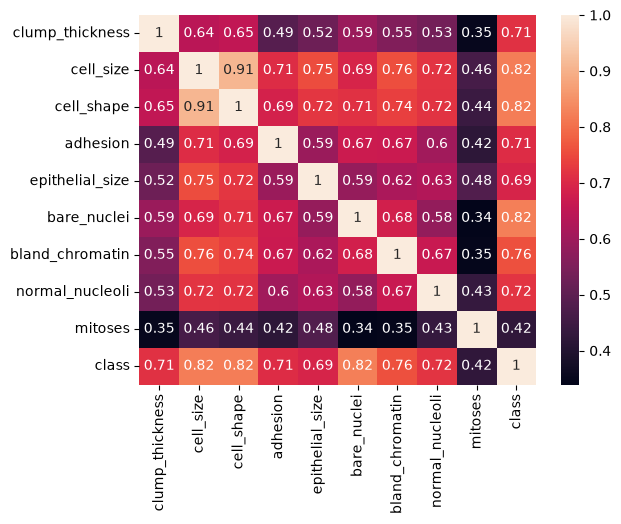

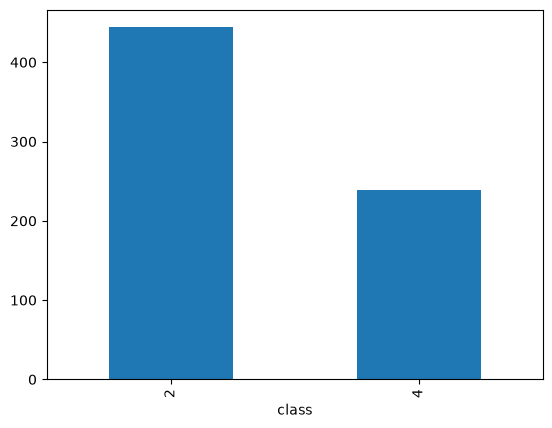

In [93]:
# drop sample id, not actual data
df = df.drop(columns='sample')

### Class (output feature)
# 2 = benign
# 4 = malignant
# All others are training input data

# drop any samples with nan/sparse values
# df.isna().sum()
# 16 NaN detected in bare_nuclei
df = df.dropna()

# Draw a correlation matrix
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

# Draw a graph for class balance
df['class'].value_counts().plot(kind="bar")
plt.show()

0.9707602339181286


c:\python\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


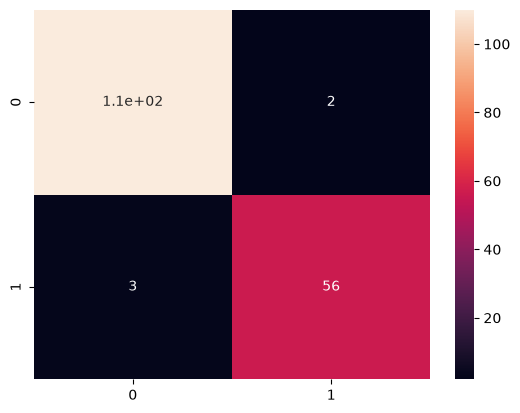

              precision    recall  f1-score   support

           2       0.97      0.98      0.98       112
           4       0.97      0.95      0.96        59

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



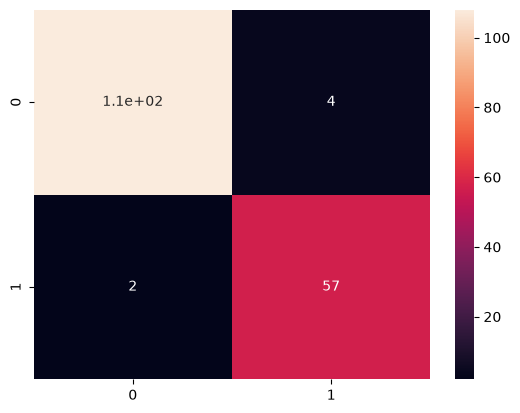

KNN with scaling: 0.9649


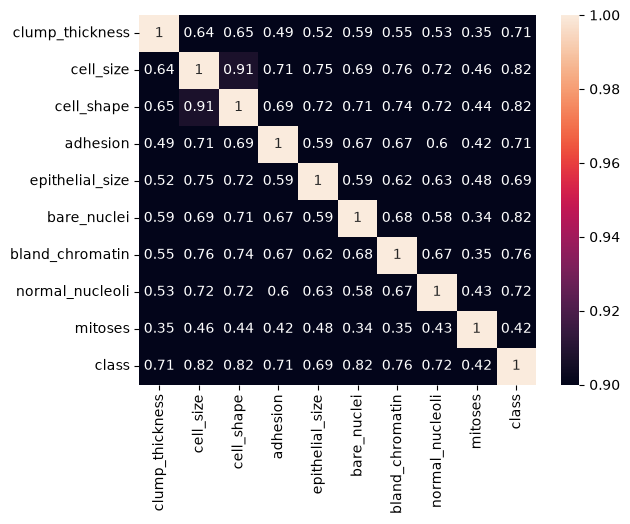

c:\python\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:783: UserWarning: k=10 is greater than n_features=9. All the features will be returned.
  warnings.warn(


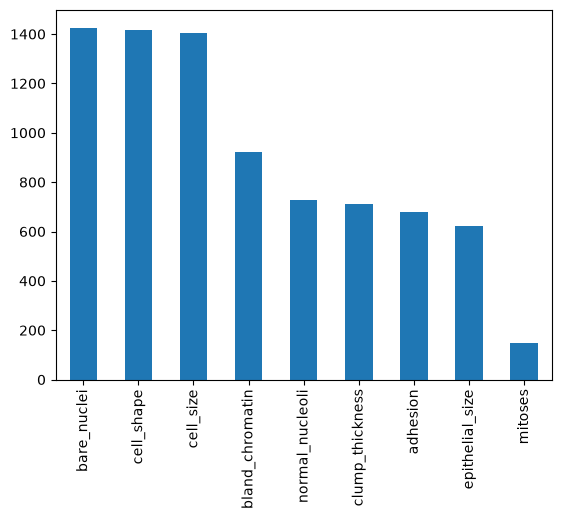

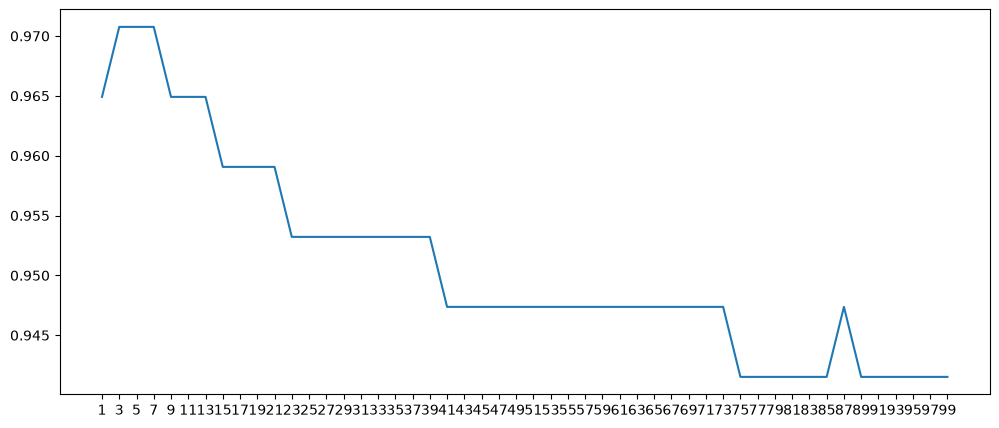

0.9590643274853801


In [94]:
# Load data, separate into input / output features
# Separate data into training / testing sets (123321 as a seed for train_test_split)
from sklearn.model_selection import train_test_split

X = df.drop(columns='class')
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123321)

# Fit a KNN estimator to the data (leave k default)
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()
model.fit(X_train, y_train)

# Make a prediction using the following for [6,2,3,1,2,1,1,1,1]
point = [[6,2,3,1,2,1,1,1,1]]
pred = model.predict(point)

# Get estimator's score
print(model.score(X_test, y_test))

# Draw a confusion matrix for the estimator
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
cmat = confusion_matrix(y_test, y_pred)
sns.heatmap(cmat, annot=True)
plt.show()

# Generate a classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

# Try using other estimators
from sklearn.naive_bayes import GaussianNB

new_model = GaussianNB()
new_model.fit(X_train, y_train)
y_pred = new_model.predict(X_test)
cmat = confusion_matrix(y_test, y_pred)
sns.heatmap(cmat, annot=True)
plt.show()

# Try using a data transformation technique
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaled = KNeighborsClassifier()
model_scaled.fit(X_train_scaled, y_train)
print(f'KNN with scaling: {model_scaled.score(X_test_scaled, y_test):.4f}')

# Answering lab questions
# colinearity
sns.heatmap(df.corr(numeric_only=True).abs(), vmin=0.9, vmax=1, annot=True)
plt.show()

# feature select
from sklearn.feature_selection import SelectKBest, f_classif
kselect = SelectKBest(score_func=f_classif)
kselect.fit(X, y)

scores = pd.Series(kselect.scores_, index=X.columns)
scores.sort_values(ascending=False).plot(kind='bar')
plt.show()

# neighbors
k_values = range(1, 101, 2)  # odd numbers 1-100 to avoid ties
scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    scores.append(model.score(X_test, y_test))

results = pd.Series(scores, index=k_values)
fig = results.plot(figsize=(12, 5))
fig.set_xticks(k_values)
plt.show()

# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=1)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

model_pca = KNeighborsClassifier()
model_pca.fit(X_train_pca, y_train)

pca_score = model_pca.score(X_test_pca, y_test)
print(pca_score)